In [1]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph,START,END,add_messages
from typing import TypedDict,List,Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage,RemoveMessage
from langchain_core.prompts import PromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages.utils import count_tokens_approximately,trim_messages


In [2]:
load_dotenv()

model = ChatOpenAI()

In [3]:
class MessageState(TypedDict):

    messages : Annotated[List[BaseMessage],add_messages]
    summary : str

In [4]:
def chat_node(state:MessageState)->dict:

    messages = state['messages']

    response = model.invoke(messages)
    print('Current token is approx :',count_tokens_approximately(messages=messages))
    return {'messages':[response]}

In [5]:
def summary(state:MessageState)->dict:

    messages = state['messages']

    messages = messages[:4]

    template = PromptTemplate(
        template = 'Summarize the following messages. \n {messages}',
        input_variables=['messages']
    )

    chain = template | model 

    response = chain.invoke({'messages':messages})

    return {'messages':[response]}
    

In [15]:
def summarize_conditions(state:MessageState):

    messages = state['messages']

    if len(messages)>6:
        return 'summary'
    else:
        return END

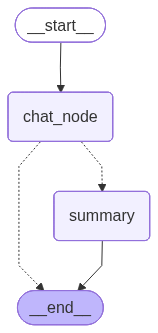

In [16]:
graph = StateGraph(MessageState)

graph.add_node('chat_node',chat_node)
graph.add_node('summary',summary)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',summarize_conditions,{'summary':'summary',END:END})
graph.add_edge('summary',END)

checkpointer = InMemorySaver()

chatbot = graph.compile(checkpointer=checkpointer)

chatbot

In [17]:
config = {'configurable':{'thread_id':'thread-1'}}

chatbot.invoke({'messages':[HumanMessage(content='My name is khan')]},config=config)
chatbot.invoke({'messages':[HumanMessage(content='I love Python')]},config=config)
chatbot.invoke({'messages':[HumanMessage(content='I am data expert')]},config=config)

Current token is approx : 8
Current token is approx : 34
Current token is approx : 110


{'messages': [HumanMessage(content='My name is khan', additional_kwargs={}, response_metadata={}, id='61e6ad4f-6e12-4b8c-952b-19a49f7d883f'),
  AIMessage(content='Nice to meet you, Khan! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 12, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DEd0HKjzI7nLQ9FPbwU6RiwHwjZUA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019caa03-aec7-7b01-9ad4-1bb694754f0a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 14, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outpu

In [23]:
chatbot.invoke({'messages':[HumanMessage(content='I Love AI and I am learning it')]},config=config)

Current token is approx : 198


{'messages': [HumanMessage(content='My name is khan', additional_kwargs={}, response_metadata={}, id='61e6ad4f-6e12-4b8c-952b-19a49f7d883f'),
  AIMessage(content='Nice to meet you, Khan! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 12, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DEd0HKjzI7nLQ9FPbwU6RiwHwjZUA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019caa03-aec7-7b01-9ad4-1bb694754f0a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 12, 'output_tokens': 14, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outpu

In [24]:
snap = chatbot.get_state(config)
for m in snap.values['messages']:
    print(f"-{m.__class__.__name__} : {m.content}")

-HumanMessage : My name is khan
-AIMessage : Nice to meet you, Khan! How can I assist you today?
-HumanMessage : I love Python
-AIMessage : That's great to hear! Python is a versatile and powerful programming language that is widely used in various fields such as web development, data science, machine learning, and more. Do you use Python for a specific purpose or just enjoy coding in it?
-HumanMessage : I am data expert
-AIMessage : That's wonderful! Python is a popular choice for data experts due to its extensive libraries and tools for data manipulation, analysis, visualization, and machine learning. Do you use any specific libraries like pandas, NumPy, matplotlib, or scikit-learn in your data analysis work?
-HumanMessage : I Love AI and I am learning it
-AIMessage : That's fantastic! Artificial Intelligence is a fascinating and rapidly evolving field with exciting possibilities. Python is a common language used in AI development due to its simplicity and the availability of powerfu